In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

In [2]:
df = pd.read_csv("data/fitness_app_data.csv", encoding="euc-kr")
df

,User_ID,Subscription_Tier,Total_Revenue,Push_Test_Group,Weekly_Active_Days,Workout_Min_Before,Workout_Min_After,Community_Posts,Retention_Days
0,1,Pro,115218.0,B_Group(맞춤형 푸시),3.0,160.0,187.0,2,97.0
1,2,Basic,34767.0,A_Group(푸시 없음),3.0,111.0,126.0,7,117.0
2,3,Premium,234525.0,A_Group(푸시 없음),3.0,152.0,184.0,5,96.0
3,4,Basic,38414.0,A_Group(푸시 없음),3.0,87.0,112.0,4,131.0
4,5,Premium,358180.0,A_Group(푸시 없음),2.0,78.0,100.0,3,88.0
...,...,...,...,...,...,...,...,...,...
3995,3996,Premium,197817.0,A_Group(푸시 없음),4.0,112.0,145.0,2,101.0
3996,3997,Basic,21915.0,A_Group(푸시 없음),4.0,113.0,125.0,5,104.0
3997,3998,Premium,293323.0,B_Group(맞춤형 푸시),4.0,110.0,129.0,5,148.0
3998,3999,Basic,50345.0,A_Group(푸시 없음),3.0,105.0,142.0,3,93.0


▶ A그룹 평균 주간 접속 일수: 2.5
▶ B그룹 평균 주간 접속 일수: 3.8
 - p-value(유의확률): 0.0000


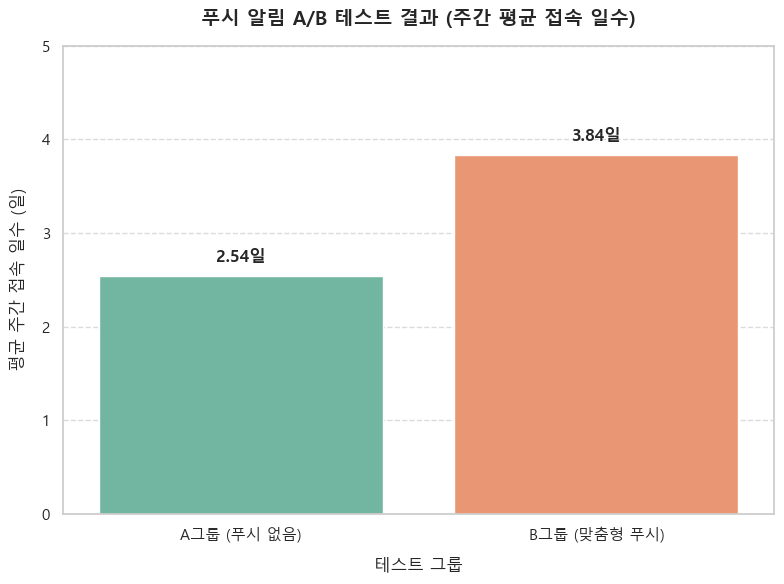


결론: 통계적으로 유의미한 차이가 있습니다. 푸시 알림이 효과를 보였습니다!


In [85]:
# 1) [A/B 테스트 검중] 푸시 알림은 정말 효과가 있었나?
group_a = df[df["Push_Test_Group"] == "A_Group(푸시 없음)"]["Weekly_Active_Days"]
group_b = df[df["Push_Test_Group"] == "B_Group(맞춤형 푸시)"]["Weekly_Active_Days"]

# 두 그룹의 직관적인 비교를 위해 각각의 평균(Mean) 주간 접속 일수를 계산
group_a_mean = group_a.mean()
group_b_mean = group_b.mean()

# 독립표본 t-검정을 수행하여 p-value(유의확률)를 계산
_, p_val_group = stats.ttest_ind(group_a, group_b, equal_var = False)
print(f"▶ A그룹 평균 주간 접속 일수: {group_a_mean:.1f}")
print(f"▶ B그룹 평균 주간 접속 일수: {group_b_mean:.1f}")
print(f" - p-value(유의확률): {p_val_group:.4f}")

# 1. 시각화용 데이터프레임 생성
plot_df = pd.DataFrame({
    'Group': ['A그룹 (푸시 없음)', 'B그룹 (맞춤형 푸시)'],
    'Mean_Active_Days': [group_a_mean, group_b_mean]
}).sort_values(by='Mean_Active_Days')

# 2. 그래프 그리기 (plt.subplots 활용)
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.barplot(x='Group', y='Mean_Active_Days', data=plot_df, 
                   palette='Set2', hue='Group', legend=False, ax=ax)

# 3. 바 차트 상단에 정확한 평균 수치(레이블) 추가
for bar in bars.patches:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, 
            yval + 0.1, 
            f"{yval:.2f}일", 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# 4. 축 이름, 제목 및 스타일 지정
ax.set_title('푸시 알림 A/B 테스트 결과 (주간 평균 접속 일수)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('테스트 그룹', fontsize=12, labelpad=10)
ax.set_ylabel('평균 주간 접속 일수 (일)', fontsize=12, labelpad=10)
ax.set_ylim(0, 5)  # 상단 레이블이 잘리지 않도록 y축 여유 공간 확보

# 배경에 은은한 그리드 라인 추가
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 5. 여백 최적화
plt.tight_layout()
plt.show()


if p_val_group < 0.05:
    print("\n결론: 통계적으로 유의미한 차이가 있습니다. 푸시 알림이 효과를 보였습니다!")
else:
    print("\n결론: 통계적으로 유의미한 차이가 없습니다.")

▶ 도입 전(평균 운동 시간): 118.95
▶ 도입 후(평균 운동 시간): 143.99
 - p-value(유의확률): 0.0000


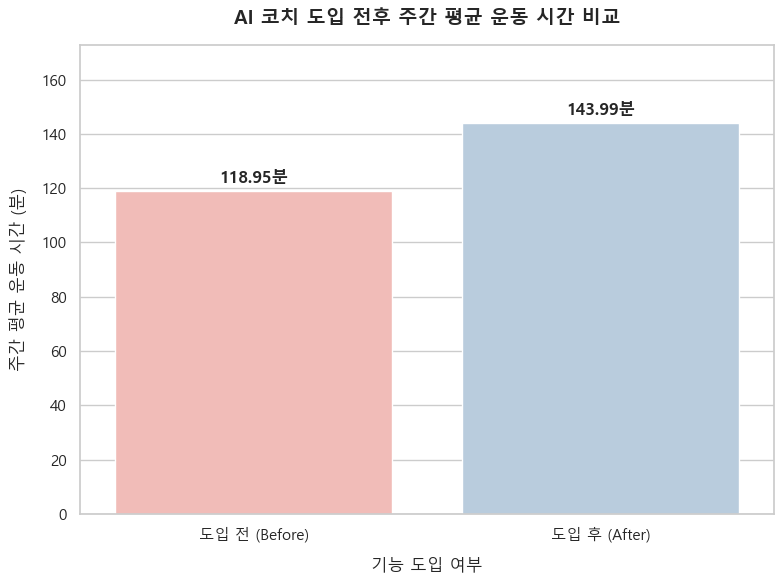


결론: 통계적으로 유의미하게 운동 시간이 증가했습니다. AI 코치 도입은 '성공'입니다!


In [66]:
# 2) [기능 업데이트 효과 검증] Ai 코치 도입, 성공인가 실패인가?
work_before = df["Workout_Min_Before"]
work_after = df["Workout_Min_After"]

before_mean = work_before.mean()
after_mean = work_after.mean()

# 동일한 유저의 사전/사후 데이터를 비교하므로 ttest_ind 대신 ttest_rel을 사용합니다.
_, p_val_ba = stats.ttest_rel(work_before, work_after)
print(f"▶ 도입 전(평균 운동 시간): {before_mean:.2f}")
print(f"▶ 도입 후(평균 운동 시간): {after_mean:.2f}")
print(f" - p-value(유의확률): {p_val_ba:.4f}")


# 1. 시각화용 데이터프레임 생성
plot_df = pd.DataFrame({
    'Status': ['도입 전 (Before)', '도입 후 (After)'],
    'Mean_Workout_Min': [before_mean, after_mean]
})

# 2. 한글 깨짐 방지 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 3. 그래프 그리기
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='Status', y='Mean_Workout_Min', data=plot_df, palette='Pastel1', hue='Status', legend=False, ax=ax)

# ★ [핵심] 가장 간단하게 막대 위에 평균시간 값 표시하기
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f분', padding=3, fontweight='bold', fontsize=12)

# 4. 제목 및 축 이름 설정
ax.set_title('AI 코치 도입 전후 주간 평균 운동 시간 비교', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('기능 도입 여부', labelpad=10)
ax.set_ylabel('주간 평균 운동 시간 (분)', labelpad=10)
ax.set_ylim(0, max(before_mean, after_mean) * 1.2)  # 숫자가 잘리지 않도록 천장 높이기

# 5. 그래프 출력
plt.tight_layout()
plt.show()

if p_val_ba < 0.05:
    print("\n결론: 통계적으로 유의미하게 운동 시간이 증가했습니다. AI 코치 도입은 '성공'입니다!")
else:
    print("\n결론: 전후 차이가 통계적으로 유의미하지 않습니다. AI 코치 도입 효과는 '판단 보류'입니다.")


▶ Basic 등급 평균 결제액: 50,524원
▶ Pro 등급 평균 결제액: 119,795원
▶ Premium 등급 평균 결제액: 250,627원

 - p-value(유의확률):0.0000


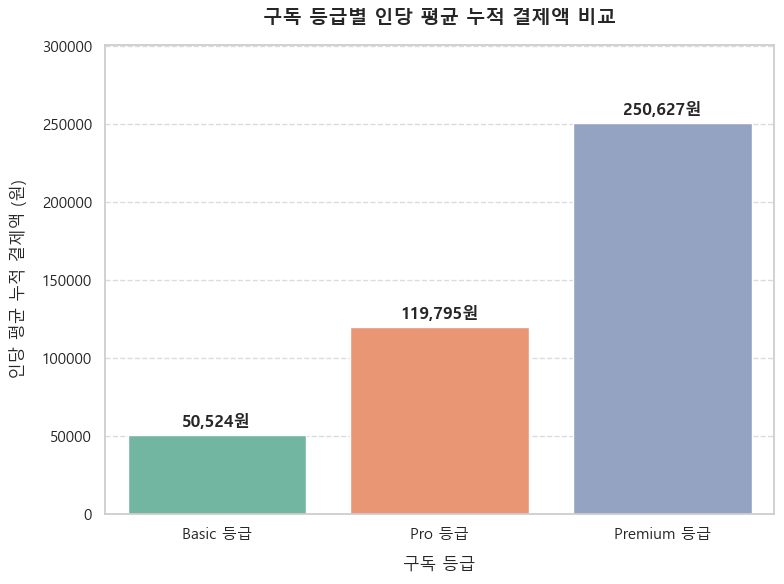

결론: 세 등급 간 누적 결제액에 통계적으로 유의미한 차이가 확실히 존재합니다!
        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
 group1  group2   meandiff   p-adj    lower        upper     reject
-------------------------------------------------------------------
  Basic Premium  200103.0474   0.0  197728.3692  202477.7256   True
  Basic     Pro   69270.9222   0.0   67199.8364    71342.008   True
Premium     Pro -130832.1252   0.0 -133390.7727 -128273.4778   True
-------------------------------------------------------------------


In [92]:
# 3) [수익성 분석]어떤 구독 등급에 마케팅을 집중해야 할까?
rev_basic = df[df["Subscription_Tier"] == "Basic"]["Total_Revenue"]
rev_pro = df[df["Subscription_Tier"] == "Pro"]["Total_Revenue"]
rev_premium = df[df["Subscription_Tier"] == "Premium"]["Total_Revenue"]

rev_basic_mean = rev_basic.mean()
rev_pro_mean = rev_pro.mean()
rev_premium_mean = rev_premium.mean()

# 총 3개 그룹으로 집단이 3개 이상이기 때문에 T-Test 대신 ANOVA를 사용하여 그룹 간 전체 매출 편차를 일괄 검정합니다.
# ANOVA 검정은 데이터의 분산(퍼짐 정도)을 봐야 하므로, 평균값이 아닌 '원본 데이터 변수'를 입력해야 합니다.
_, p_val_rev = stats.f_oneway(rev_basic, rev_pro, rev_premium)

print(f"▶ Basic 등급 평균 결제액: {rev_basic_mean:,.0f}원")
print(f"▶ Pro 등급 평균 결제액: {rev_pro_mean:,.0f}원")
print(f"▶ Premium 등급 평균 결제액: {rev_premium_mean:,.0f}원\n")
print(f" - p-value(유의확률):{p_val_rev:.4f}")

# 2. 시각화용 데이터프레임 생성 및 정렬 (★ 지침에 따라 오름차순 정렬)
plot_df = pd.DataFrame({
    '구독 등급': ['Basic 등급', 'Pro 등급', 'Premium 등급'],
    '평균 결제액': [rev_basic_mean, rev_pro_mean, rev_premium_mean]
}).sort_values(by='평균 결제액')

# 3. 한글 깨짐 방지 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 4. 막대그래프 그리기 (plt.subplots 구조 활용)
fig, ax = plt.subplots(figsize=(8, 6))

# palette와 hue를 매칭하여 최신 Seaborn 버전 경고를 해결하고 범례도 가립니다.
bars = sns.barplot(x='구독 등급', y='평균 결제액', data=plot_df, 
                   palette='Set2', hue='구독 등급', legend=False, ax=ax)

# ★ [핵심] 가장 간결한 문법으로 막대 상단에 세 자릿수 쉼표(,)와 '원'이 포함된 금액 표시
for container in ax.containers:
    ax.bar_label(container, labels=[f'{x:,.0f}원' for x in container.datavalues], 
                 padding=3, fontweight='bold', fontsize=12)

# 5. 차트 세부 디자인 및 제목 설정 (올려주신 그래프 스타일 반영)
ax.set_title('구독 등급별 인당 평균 누적 결제액 비교', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('구독 등급', labelpad=10)
ax.set_ylabel('인당 평균 누적 결제액 (원)', labelpad=10)

# 수치 레이블이 차트 상단에 잘리지 않도록 y축 천장을 넉넉히 확보
ax.set_ylim(0, max(plot_df['평균 결제액']) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 그래프 저장
plt.tight_layout()
plt.show()


if p_val_rev < 0.05:
    print("결론: 세 등급 간 누적 결제액에 통계적으로 유의미한 차이가 확실히 존재합니다!")
    tukey = pairwise_tukeyhsd(endog=df["Total_Revenue"], groups=df["Subscription_Tier"], alpha=0.05)
    print(tukey)

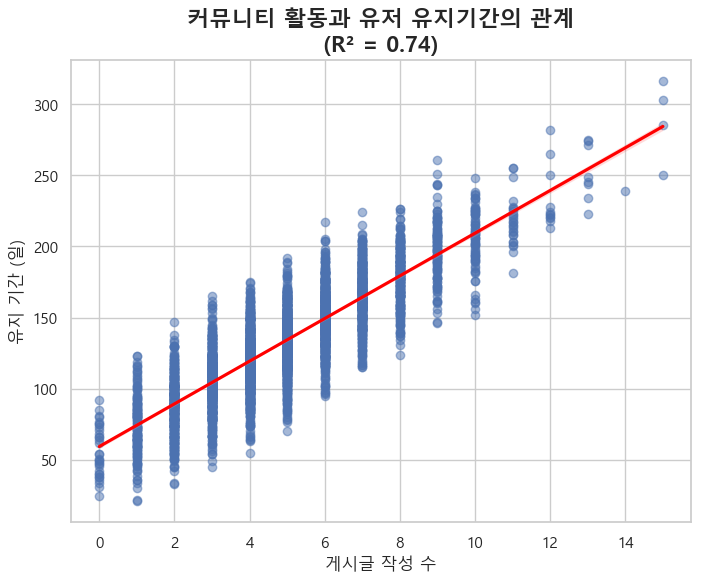

▶ [커뮤니티 활동 기반 유지기간 예측 공식]
 - 예측 유지기간 = (14.99 x 게시글 수) + 59.43일
 - 회귀결정계수(R²): 73.6%
 - p-value: 0.0000


In [93]:
# 4) [미래 예측 시뮬레이션] 커뮤니티 활성화가 수명(Retention)에 미치는 영향
reg = stats.linregress(df["Community_Posts"], df["Retention_Days"])
r_squared = reg.rvalue ** 2

# 시각화
plt.figure(figsize=(8, 6))

sns.regplot(
    x="Community_Posts",
    y="Retention_Days",
    data=df,
    line_kws={"color": "red"},
    scatter_kws={"alpha": 0.5}
)

plt.title(
    f"커뮤니티 활동과 유저 유지기간의 관계\n(R² = {r_squared:.2f})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("게시글 작성 수")
plt.ylabel("유지 기간 (일)")
plt.show()

# 결과 출력
print("▶ [커뮤니티 활동 기반 유지기간 예측 공식]")
print(f" - 예측 유지기간 = ({reg.slope:.2f} x 게시글 수) + {reg.intercept:.2f}일")
print(f" - 회귀결정계수(R²): {r_squared * 100:.1f}%")
print(f" - p-value: {reg.pvalue:.4f}")